## Setup

In [1]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
import time
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns


In [2]:
train_dir = "Traffic_Sign/Train"
test_dir  = "Traffic_Sign/Test"

In [3]:
print(tf.config.list_physical_devices('GPU'))
print(tf.test.gpu_device_name())

[]



In [4]:
tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(4)
print("Running on CPU with optimized threading.")

Running on CPU with optimized threading.


## Data Understanding, Analysis, Visualization and Cleaning

#### Get Class Names

In [5]:
def get_class_names(directory):
    class_names = sorted(os.listdir(directory))
    if not class_names:
        print("No class directories found!")
    else:
        print(f"Found {len(class_names)} classes: {class_names}")

print("For train directory")
get_class_names(train_dir)

For train directory
Found 4 classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


### Check Corrupt image

In [6]:
def check_corrupt_images(directory):
    corrupted_images = []
    class_names = sorted(os.listdir(directory))
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            images = os.listdir(class_path)
            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                except (IOError, UnidentifiedImageError):
                    corrupted_images.append(img_path)
    if corrupted_images:
        print(f"\nCorrupted Images Found in {directory}:")
        for img in corrupted_images:
            print(img)
    else:
        print(f"\nNo corrupted images found in {directory}")

check_corrupt_images(train_dir)


No corrupted images found in Traffic_Sign/Train


### Clean Corrupt images

In [7]:
from PIL import Image, UnidentifiedImageError
import os

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')

def clean_directory(directory):
    removed = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            # Remove non-image extensions
            if not file.lower().endswith(valid_extensions):
                os.remove(filepath)
                removed += 1
                continue
            # Try opening with PIL
            try:
                with Image.open(filepath) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                os.remove(filepath)
                removed += 1
    print(f"Removed {removed} bad files from {directory}")

clean_directory(train_dir)

Removed 0 bad files from Traffic_Sign/Train


### Count Classes


In [8]:
def count_class(directory):
    class_names = sorted(os.listdir(directory))
    class_counts = {}
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            images = [img for img in os.listdir(class_path)
                      if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(images)
    print("\nClass Distribution:")
    print("=" * 45)
    print(f"{'Class Name':<25}{'Valid Image Count':>15}")
    print("=" * 45)
    for class_name, count in class_counts.items():
        print(f"{class_name:<25}{count:>15}")
    print("=" * 45)

print("Train directory")
count_class(train_dir)

Train directory

Class Distribution:
Class Name               Valid Image Count
Caution                             2422
Instructions                        2841
No Passing                          5362
OverSpeed                           5242


### Sample visualization

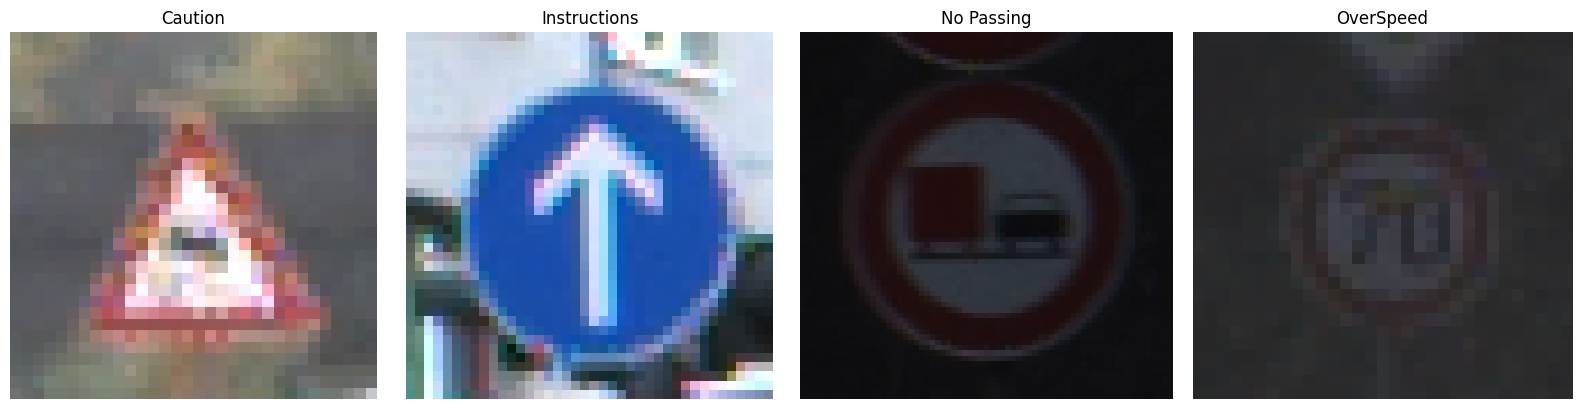

In [9]:
selected_images = []
selected_labels = []
class_names = sorted(os.listdir(train_dir))

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = num_classes
rows = 1
fig, axes = plt.subplots(rows, cols, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()

## Part A: Designing and Analyzing CNNs from Scratch

### Load Dataset

In [10]:
img_height = 128
img_width  = 128
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='training'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_height, img_width),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='validation'
)

num_classes = len(train_ds.class_names)
class_names = train_ds.class_names
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 15867 files belonging to 4 classes.
Using 12694 files for training.
Found 15867 files belonging to 4 classes.
Using 3173 files for validation.
Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Num classes: 4


### Class weights

In [11]:
from sklearn.utils.class_weight import compute_class_weight

all_labels = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in train_ds])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.6417485773409208), 1: np.float64(1.4054472984942428), 2: np.float64(0.7402612549568462), 3: np.float64(0.7527277039848197)}


### Baseline model

In [12]:
baseline_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,298,148 (16.40 MB)

 Trainable params: 4,298,148 (16.40 MB)

 Non-trainable params: 0 (0.00 B)

### Compile Baseline

In [13]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Early Stopping

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Train Baseline

In [15]:
start_time = time.time()
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)
baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 38s 93ms/step - accuracy: 0.9078 - loss: 0.2616 - val_accuracy: 0.9817 - val_loss: 0.0627
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.9853 - loss: 0.0525 - val_accuracy: 0.9893 - val_loss: 0.0387
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.9931 - loss: 0.0249 - val_accuracy: 0.9940 - val_loss: 0.0200
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.9969 - loss: 0.0090 - val_accuracy: 0.9946 - val_loss: 0.0208
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - accuracy: 0.9898 - loss: 0.0374 - val_accuracy: 0.9975 - val_loss: 0.0145
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.9983 - loss: 0.0058 - val_accuracy: 0.9918 - val_loss: 0.0345
Epoch 7/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.9935 - loss: 0.0197 - val_accuracy: 0.9965 - val_loss: 0.0250
Epoch 8/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.9950 - loss: 0.0202 -

### Plot Baseline

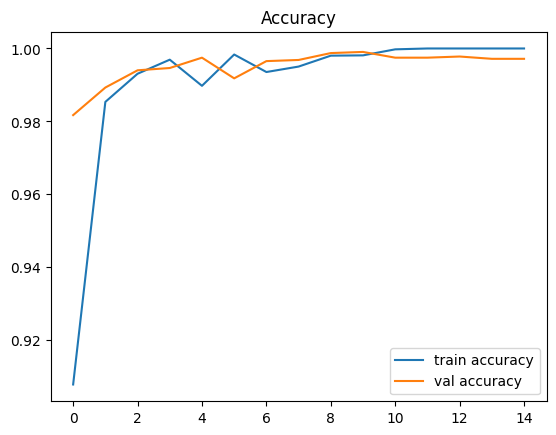

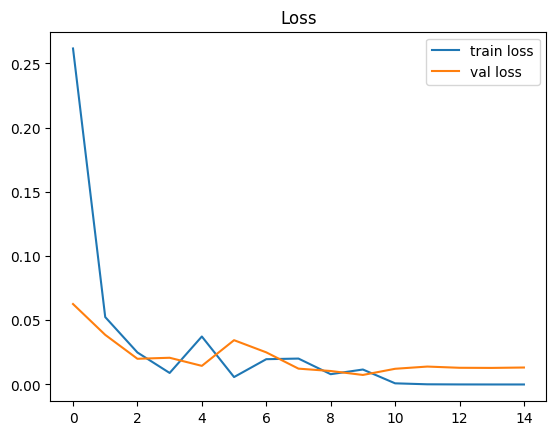

In [16]:
plt.plot(baseline_history.history['accuracy'], label='train accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(baseline_history.history['loss'], label='train loss')
plt.plot(baseline_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

### Evaluate Baselined

In [17]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = baseline_model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(num_classes)))


Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       489
Instructions       1.00      1.00      1.00       583
  No Passing       1.00      1.00      1.00      1075
   OverSpeed       1.00      1.00      1.00      1026

    accuracy                           1.00      3173
   macro avg       1.00      1.00      1.00      3173
weighted avg       1.00      1.00      1.00      3173



### Data Augmentation

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

### Visualize Augmented Images

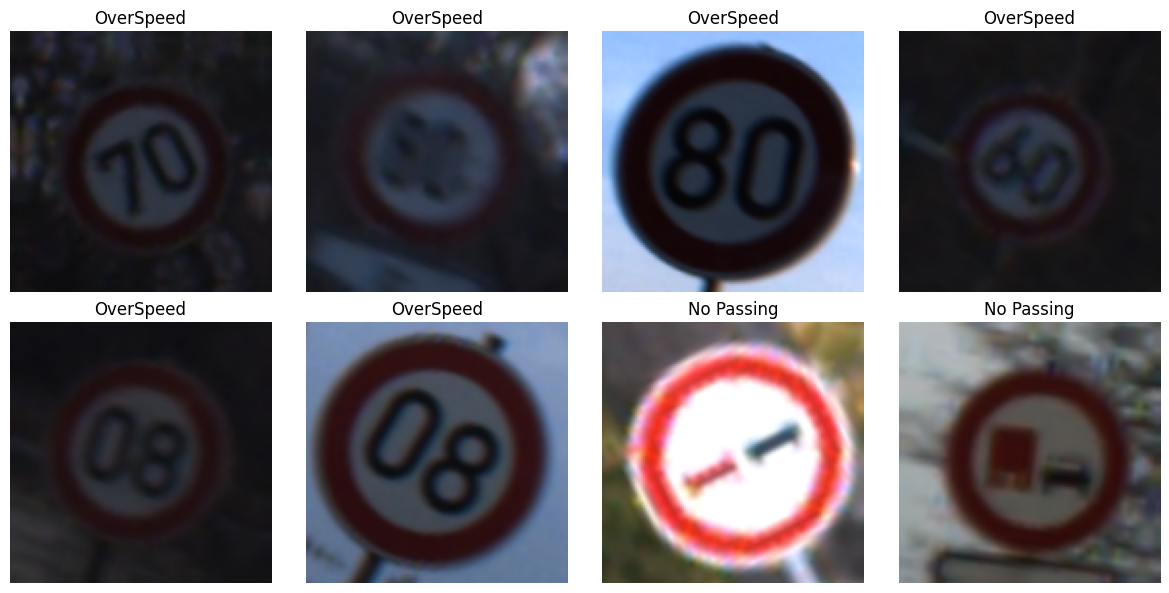

In [ ]:
images, labels = next(iter(train_ds_aug))
plt.figure(figsize=(12, 6))

for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

### Deeper Architecture with Regularization

In [20]:
deeper_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 5
    layers.Conv2D(512, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 6
    layers.Conv2D(1024, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,667,812 (25.44 MB)

 Trainable params: 6,663,780 (25.42 MB)

 Non-trainable params: 4,032 (15.75 KB)

### Compile Deeper Model

In [21]:
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Train Deeper Model (Adam)

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

deeper_start_time = time.time()
deeper_history = deeper_model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)
deeper_train_time = time.time() - deeper_start_time
print(f"Deeper training time: {deeper_train_time:.2f} seconds")

Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 133s 328ms/step - accuracy: 0.7360 - loss: 0.6165 - val_accuracy: 0.8875 - val_loss: 0.3703
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 128s 322ms/step - accuracy: 0.9564 - loss: 0.1355 - val_accuracy: 0.9905 - val_loss: 0.0299
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 126s 317ms/step - accuracy: 0.9827 - loss: 0.0555 - val_accuracy: 0.9379 - val_loss: 0.1892
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 135s 338ms/step - accuracy: 0.9877 - loss: 0.0358 - val_accuracy: 0.9584 - val_loss: 0.0903
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 129s 324ms/step - accuracy: 0.9912 - loss: 0.0309 - val_accuracy: 0.9905 - val_loss: 0.0269
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 131s 328ms/step - accuracy: 0.9941 - loss: 0.0182 - val_accuracy: 0.9959 - val_loss: 0.0127
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 131s 329ms/step - accuracy: 0.9920 - loss: 0.0223 - val_accuracy: 0.9984 - val_loss: 0.0053
Epoch 8/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 132s 331ms/step - accuracy: 0.9963 -

### Plot deeper Model (Adam)

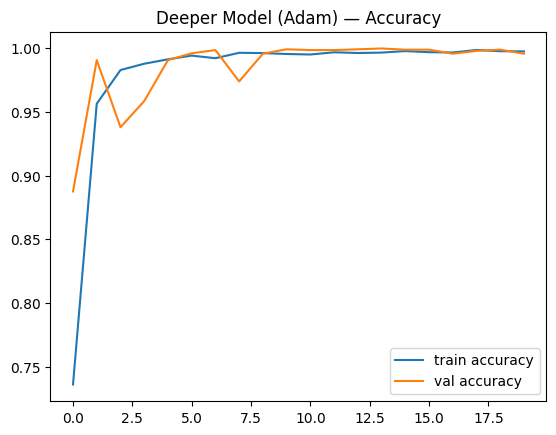

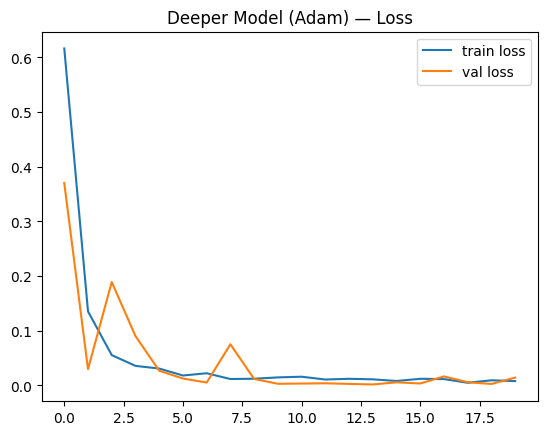

In [23]:
plt.plot(deeper_history.history['accuracy'], label='train accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Deeper Model (Adam) — Accuracy")
plt.show()

plt.plot(deeper_history.history['loss'], label='train loss')
plt.plot(deeper_history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Deeper Model (Adam) — Loss")
plt.show()

### Evaluate Deeper Model (Adam)


Classification Report — Deeper Model (Adam):
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       489
Instructions       1.00      1.00      1.00       583
  No Passing       1.00      1.00      1.00      1075
   OverSpeed       1.00      1.00      1.00      1026

    accuracy                           1.00      3173
   macro avg       1.00      1.00      1.00      3173
weighted avg       1.00      1.00      1.00      3173



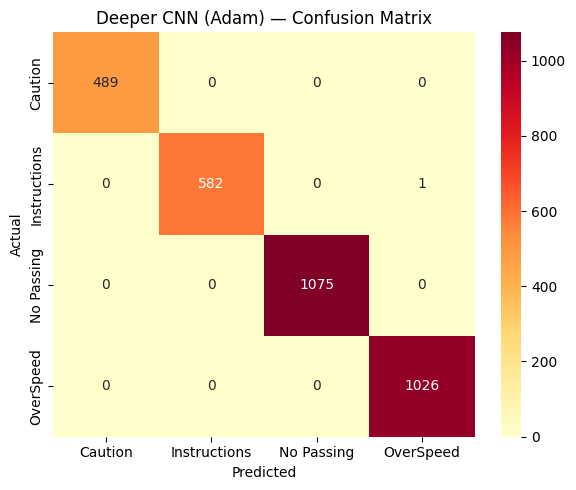

In [24]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = deeper_model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report — Deeper Model (Adam):")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(num_classes)))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper CNN (Adam) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### With SGD Optimizer

In [25]:
deeper_model_sgd = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 5
    layers.Conv2D(512, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 6
    layers.Conv2D(1024, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
deeper_model_sgd.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,667,812 (25.44 MB)

 Trainable params: 6,663,780 (25.42 MB)

 Non-trainable params: 4,032 (15.75 KB)

### Train 

In [26]:
deeper_model_sgd.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

sgd_start_time = time.time()
deeper_history_sgd = deeper_model_sgd.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)
sgd_train_time = time.time() - sgd_start_time
print(f"Deeper SGD training time: {sgd_train_time:.2f} seconds")

Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 121s 301ms/step - accuracy: 0.5744 - loss: 0.9092 - val_accuracy: 0.5717 - val_loss: 0.9558
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 119s 298ms/step - accuracy: 0.8742 - loss: 0.3395 - val_accuracy: 0.9042 - val_loss: 0.2371
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 128s 321ms/step - accuracy: 0.9430 - loss: 0.1771 - val_accuracy: 0.9864 - val_loss: 0.0489
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 155s 390ms/step - accuracy: 0.9626 - loss: 0.1136 - val_accuracy: 0.9543 - val_loss: 0.1274
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 158s 397ms/step - accuracy: 0.9801 - loss: 0.0640 - val_accuracy: 0.9915 - val_loss: 0.0252
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 130s 327ms/step - accuracy: 0.9829 - loss: 0.0494 - val_accuracy: 0.9326 - val_loss: 0.1695
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 122s 307ms/step - accuracy: 0.9858 - loss: 0.0449 - val_accuracy: 0.9959 - val_loss: 0.0123
Epoch 8/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 123s 308ms/step - accuracy: 0.9906 -

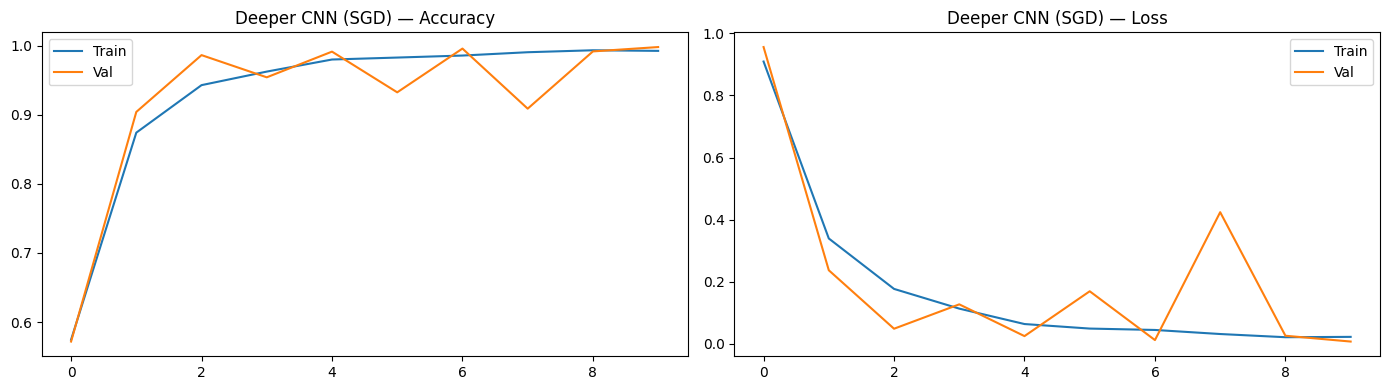

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(deeper_history_sgd.history['accuracy'], label='Train')
axes[0].plot(deeper_history_sgd.history['val_accuracy'], label='Val')
axes[0].set_title('Deeper CNN (SGD) — Accuracy')
axes[0].legend()

axes[1].plot(deeper_history_sgd.history['loss'], label='Train')
axes[1].plot(deeper_history_sgd.history['val_loss'], label='Val')
axes[1].set_title('Deeper CNN (SGD) — Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


Classification Report — Deeper Model (SGD):
              precision    recall  f1-score   support

     Caution       0.60      0.19      0.29       489
Instructions       1.00      0.44      0.61       583
  No Passing       0.50      0.99      0.66      1075
   OverSpeed       0.65      0.39      0.48      1026

    accuracy                           0.57      3173
   macro avg       0.69      0.50      0.51      3173
weighted avg       0.65      0.57      0.54      3173



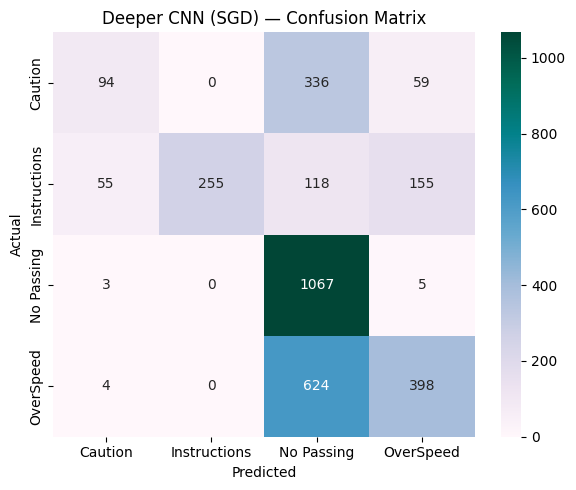

In [28]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = deeper_model_sgd.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report — Deeper Model (SGD):")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(num_classes)))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBuGn',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper CNN (SGD) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

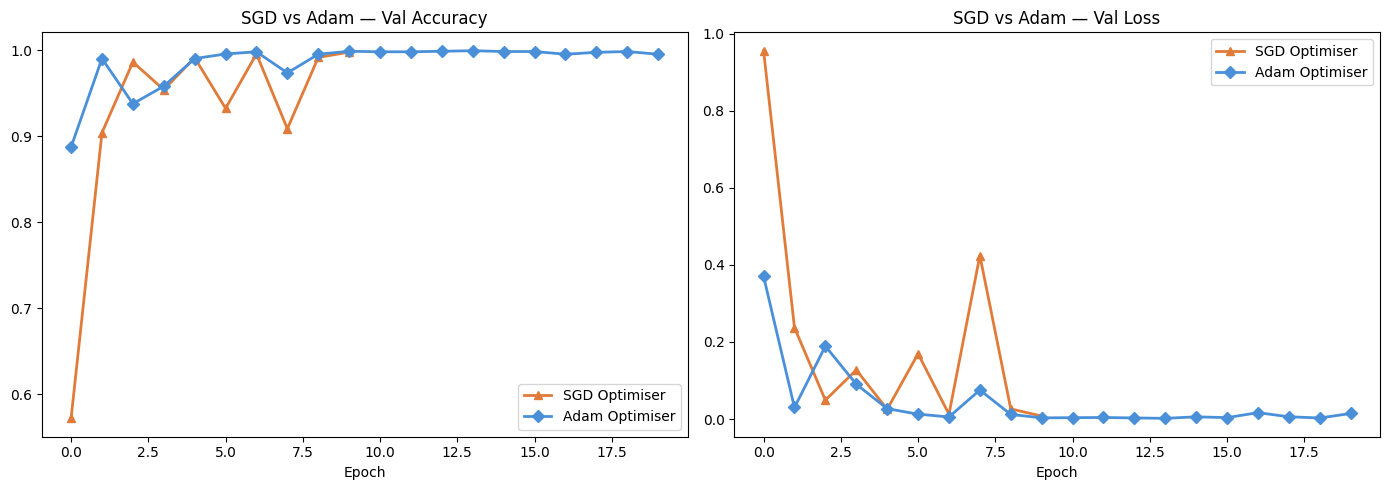

=== SGD vs Adam Comparison ===
SGD  — Best Val Acc: 0.9981 | Time: 1303.07s
Adam — Best Val Acc: 0.9997 | Time: 2623.21s


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history_sgd.history['val_accuracy'], label='SGD Optimiser', color='#e07b39', marker='^', linewidth=2)
axes[0].plot(deeper_history.history['val_accuracy'], label='Adam Optimiser', color='#4a90d9', marker='D', linewidth=2)
axes[0].set_title('SGD vs Adam — Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(deeper_history_sgd.history['val_loss'], label='SGD Optimiser', color='#e07b39', marker='^', linewidth=2)
axes[1].plot(deeper_history.history['val_loss'], label='Adam Optimiser', color='#4a90d9', marker='D', linewidth=2)
axes[1].set_title('SGD vs Adam — Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print("=== SGD vs Adam Comparison ===")
print(f"SGD  — Best Val Acc: {max(deeper_history_sgd.history['val_accuracy']):.4f} | Time: {sgd_train_time:.2f}s")
print(f"Adam — Best Val Acc: {max(deeper_history.history['val_accuracy']):.4f} | Time: {deeper_train_time:.2f}s")

In [30]:
model_ablation = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(512, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),   # No Dropout
    layers.Dense(256, activation='relu'),   # No Dropout
    layers.Dense(128, activation='relu'),   # No Dropout
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
], name='Ablation_No_Dropout')

model_ablation.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ablation_start = time.time()
history_ablation = model_ablation.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)
ablation_time = time.time() - ablation_start
print(f"Ablation training time: {ablation_time:.2f}s")
print(f"Best Val Acc (No Dropout): {max(history_ablation.history['val_accuracy']):.4f}")
print(f"Best Val Acc (With Dropout): {max(deeper_history.history['val_accuracy']):.4f}")

Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 118s 289ms/step - accuracy: 0.7521 - loss: 0.6088 - val_accuracy: 0.6202 - val_loss: 0.9403
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 117s 293ms/step - accuracy: 0.9449 - loss: 0.1652 - val_accuracy: 0.9786 - val_loss: 0.0745
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 116s 291ms/step - accuracy: 0.9764 - loss: 0.0750 - val_accuracy: 0.9770 - val_loss: 0.0610
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 115s 288ms/step - accuracy: 0.9791 - loss: 0.0641 - val_accuracy: 0.9616 - val_loss: 0.1391
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 114s 287ms/step - accuracy: 0.9876 - loss: 0.0370 - val_accuracy: 0.9956 - val_loss: 0.0142
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 118s 295ms/step - accuracy: 0.9881 - loss: 0.0358 - val_accuracy: 0.9720 - val_loss: 0.0778
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 116s 291ms/step - accuracy: 0.9913 - loss: 0.0284 - val_accuracy: 0.9978 - val_loss: 0.0067
Epoch 8/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 116s 290ms/step - accuracy: 0.9941 -

### ## Part B: Transfer Learning — MobileNetV2

In [31]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

tl_img_size = 96

train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(tl_img_size, tl_img_size),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='training'
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(tl_img_size, tl_img_size),
    interpolation='bilinear',
    batch_size=batch_size,
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='validation'
)

# Augmentation + MobileNetV2 preprocessing
data_aug_tl = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation_tl")

AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = train_ds_tl.map(
    lambda x, y: (data_aug_tl(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

train_ds_tl = train_ds_tl.map(lambda x, y: (preprocess_input(x), y))
val_ds_tl   = val_ds_tl.map(lambda x, y: (preprocess_input(x), y))

print("TL Dataset ready.")

Found 15867 files belonging to 4 classes.
Using 12694 files for training.
Found 15867 files belonging to 4 classes.
Using 3173 files for validation.
TL Dataset ready.


In [32]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze all layers

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model_tl = Model(inputs=base_model.input, outputs=output, name='MobileNetV2_Transfer')

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_tl.summary()

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
early_stop_tl = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

tl_start_time = time.time()
tl_phase1_history = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[early_stop_tl],
    class_weight=class_weights_dict
)
tl_train_time = time.time() - tl_start_time
print(f"Phase 1 (Feature Extraction) time: {tl_train_time:.2f} seconds")

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.8878 - loss: 0.2976 - val_accuracy: 0.9738 - val_loss: 0.0676
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.9559 - loss: 0.1300 - val_accuracy: 0.9868 - val_loss: 0.0433
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9694 - loss: 0.0898 - val_accuracy: 0.9858 - val_loss: 0.0381
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9715 - loss: 0.0825 - val_accuracy: 0.9839 - val_loss: 0.0431
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9739 - loss: 0.0787 - val_accuracy: 0.9899 - val_loss: 0.0296
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9775 - loss: 0.0648 - val_accuracy: 0.9849 - val_loss: 0.0380
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.9787 - loss: 0.0568 - val_accuracy: 0.9918 - val_loss: 0.0248
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9797 - loss: 0.0615 - 

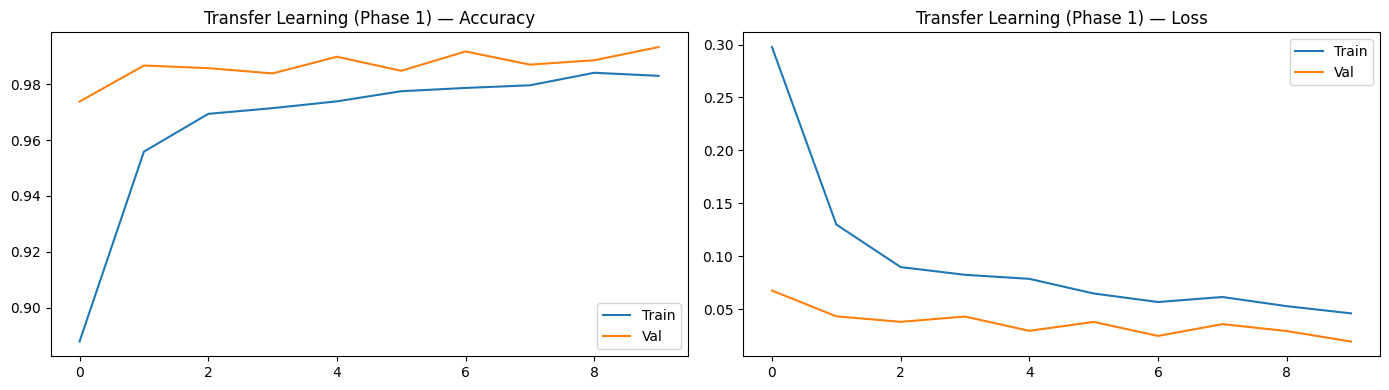

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(tl_phase1_history.history['accuracy'], label='Train')
axes[0].plot(tl_phase1_history.history['val_accuracy'], label='Val')
axes[0].set_title('Transfer Learning (Phase 1) — Accuracy')
axes[0].legend()

axes[1].plot(tl_phase1_history.history['loss'], label='Train')
axes[1].plot(tl_phase1_history.history['val_loss'], label='Val')
axes[1].set_title('Transfer Learning (Phase 1) — Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [35]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in model_tl.layers if l.trainable)}")

model_tl.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ft_start_time = time.time()
ft_phase2_history = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=[early_stop_tl],
    class_weight=class_weights_dict
)
ft_train_time = time.time() - ft_start_time
print(f"Phase 2 (Fine Tuning) time: {ft_train_time:.2f} seconds")
print(f"Best Val Acc: {max(ft_phase2_history.history['val_accuracy']):.4f}")

Trainable layers: 36
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.8363 - loss: 0.8043 - val_accuracy: 0.9858 - val_loss: 0.0395
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.9358 - loss: 0.2261 - val_accuracy: 0.9871 - val_loss: 0.0376
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.9590 - loss: 0.1505 - val_accuracy: 0.9890 - val_loss: 0.0287
Phase 2 (Fine Tuning) time: 82.33 seconds
Best Val Acc: 0.9890


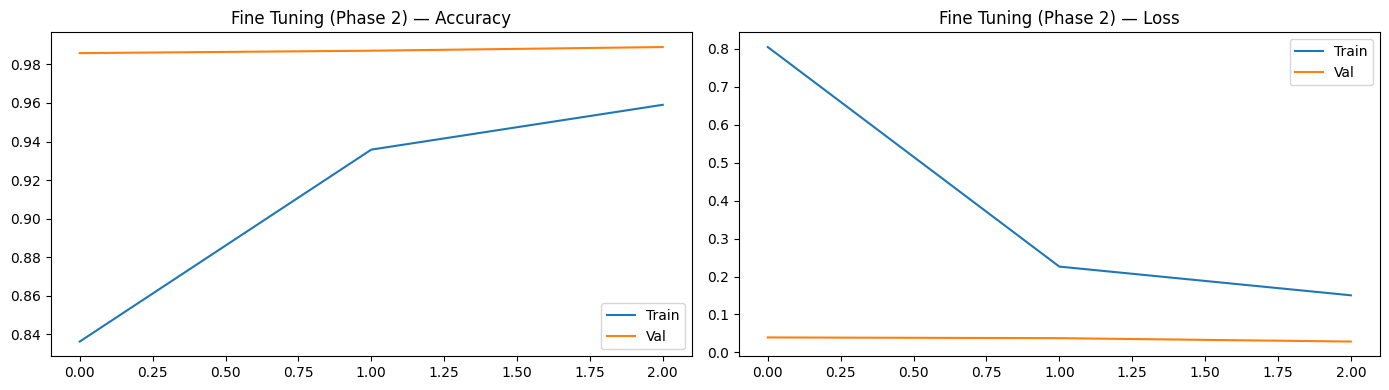

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ft_phase2_history.history['accuracy'], label='Train')
axes[0].plot(ft_phase2_history.history['val_accuracy'], label='Val')
axes[0].set_title('Fine Tuning (Phase 2) — Accuracy')
axes[0].legend()

axes[1].plot(ft_phase2_history.history['loss'], label='Train')
axes[1].plot(ft_phase2_history.history['val_loss'], label='Val')
axes[1].set_title('Fine Tuning (Phase 2) — Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

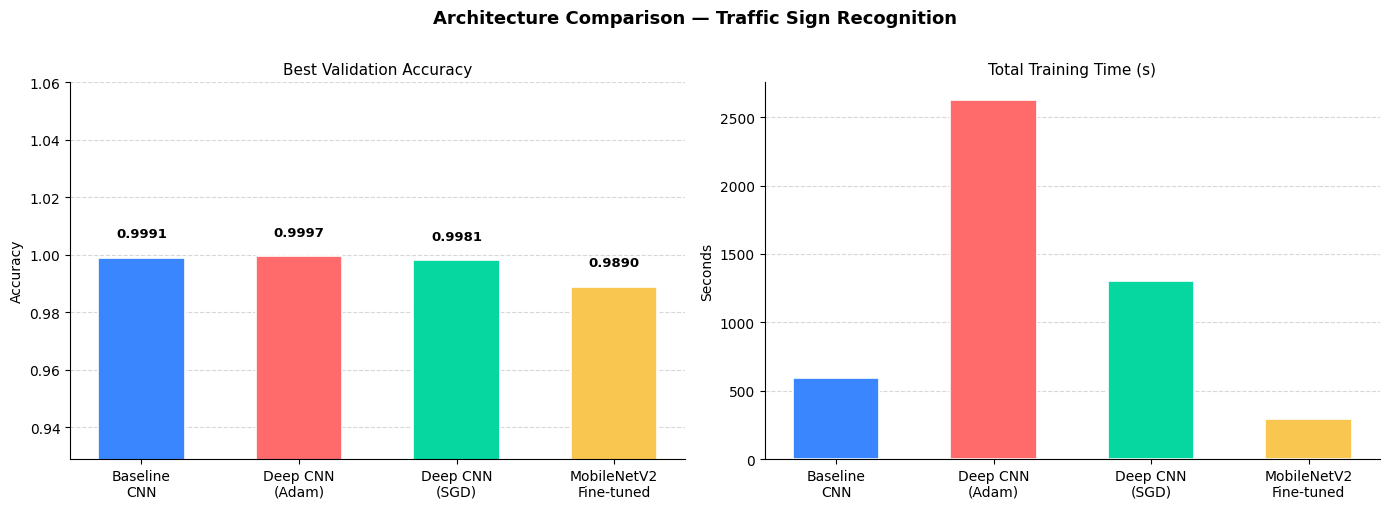


=== Architecture Performance Summary ===
Model                        Val Accuracy     Train Time
------------------------------------------------------------
Baseline CNN                 0.9991           590.90s
Deep CNN (Adam)              0.9997           2623.21s
Deep CNN (SGD)               0.9981           1303.07s
MobileNetV2 Fine-tuned       0.9890           294.19s


In [37]:
# Collect best validation accuracies for each model
cnn_base_best   = max(baseline_history.history['val_accuracy'])
cnn_adam_best   = max(deeper_history.history['val_accuracy'])
cnn_sgd_best    = max(deeper_history_sgd.history['val_accuracy'])
mobilenet_best  = max(ft_phase2_history.history['val_accuracy'])

# Collect total training durations
cnn_base_duration   = baseline_train_time
cnn_adam_duration   = deeper_train_time
cnn_sgd_duration    = sgd_train_time
mobilenet_duration  = tl_train_time + ft_train_time

arch_labels   = ['Baseline\nCNN', 'Deep CNN\n(Adam)', 'Deep CNN\n(SGD)', 'MobileNetV2\nFine-tuned']
val_scores    = [cnn_base_best, cnn_adam_best, cnn_sgd_best, mobilenet_best]
time_taken    = [cnn_base_duration, cnn_adam_duration, cnn_sgd_duration, mobilenet_duration]
bar_palette   = ['#3a86ff', '#ff6b6b', '#06d6a0', '#f9c74f']

fig, (ax_acc, ax_time) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Architecture Comparison — Traffic Sign Recognition', fontsize=13, fontweight='bold', y=1.01)

# --- Accuracy bars ---
rects = ax_acc.bar(arch_labels, val_scores, color=bar_palette, edgecolor='white', linewidth=1.2, width=0.55)
ax_acc.set_ylim(min(val_scores) - 0.06, 1.06)
ax_acc.set_title('Best Validation Accuracy', fontsize=11)
ax_acc.set_ylabel('Accuracy', fontsize=10)
ax_acc.spines[['top', 'right']].set_visible(False)
ax_acc.yaxis.grid(True, linestyle='--', alpha=0.5)
ax_acc.set_axisbelow(True)
for rect, score in zip(rects, val_scores):
    ax_acc.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 0.006,
        f'{score:.4f}',
        ha='center', va='bottom', fontsize=9.5, fontweight='bold'
    )

# --- Time bars ---
ax_time.bar(arch_labels, time_taken, color=bar_palette, edgecolor='white', linewidth=1.2, width=0.55)
ax_time.set_title('Total Training Time (s)', fontsize=11)
ax_time.set_ylabel('Seconds', fontsize=10)
ax_time.spines[['top', 'right']].set_visible(False)
ax_time.yaxis.grid(True, linestyle='--', alpha=0.5)
ax_time.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("\n=== Architecture Performance Summary ===")
print(f"{'Model':<28} {'Val Accuracy':<16} {'Train Time'}")
print("-" * 60)
for lbl, score, dur in zip(arch_labels, val_scores, time_taken):
    clean = lbl.replace('\n', ' ')
    print(f"{clean:<28} {score:.4f}           {dur:.2f}s")
